# Week 6 — Probing GPT-2's internals

Load GPT-2 (124M params) from HuggingFace →
inspect the parameter breakdown → visualize attention patterns and measure
their rank → analyze the residual stream layer by layer → prune
attention heads and measure impact → explore the embedding space → vary
softmax temperature and observe attention sharpness.



In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from transformers import GPT2LMHeadModel, GPT2Tokenizer

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cpu


## Setup — Load GPT-2

GPT-2 small: 124M parameters, 12 layers, 12 heads per layer, $d = 768$,
vocabulary size 50,257. We load the pretrained model and tokenizer from
HuggingFace.

In [ ]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2', output_attentions=True).to(device)
model.eval()

print(f"Model: GPT-2 small")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Layers: {model.config.n_layer}")
print(f"Heads: {model.config.n_head}")
print(f"d_model: {model.config.n_embd}")
print(f"Vocab: {model.config.vocab_size}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: GPT-2 small
Parameters: 124,439,808
Layers: 12
Heads: 12
d_model: 768
Vocab: 50257


## Part 1 — Where do the parameters live?

A transformer has three main components: embeddings, attention, and the
feed-forward network (FFN). Before probing the model's behavior, let's
understand its structure quantitatively.

In [ ]:
def parameter_breakdown(model):
    '''Count parameters by component type.'''
    counts = {
        'token_embedding': 0,
        'position_embedding': 0,
        'attention': 0,
        'ffn': 0,
        'layernorm': 0,
        'output_head': 0,
    }

    for name, p in model.named_parameters():
        n = p.numel()
        # TODO: Implement parameter categorization using name matching
        # Hint: Look for strings like 'wte', 'wpe', 'attn', 'mlp', 'ln', and 'lm_head'
        pass

    return counts

counts = parameter_breakdown(model)
total = sum(counts.values())

# TODO: Print a summary table showing Component, Count, and Fraction (c/total)
# Hint: Use f-string formatting for alignment and percentages

Parameter breakdown:
  Component                     Count   Fraction
  ──────────────────────────────────────────────
  token_embedding          38,597,376      31.0%
  position_embedding          786,432       0.6%
  attention                28,348,416      22.8%
  ffn                      56,669,184      45.5%
  layernorm                    38,400       0.0%
  output_head                       0       0.0%
  ──────────────────────────────────────────────
  Total                   124,439,808


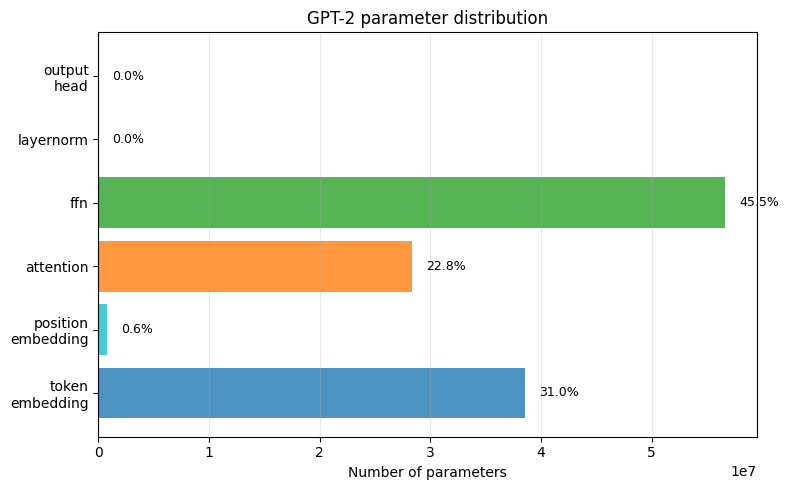

In [ ]:
# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
labels = [k.replace('_', '\n') for k in counts.keys()]
values = list(counts.values())
colors = ['tab:blue', 'tab:cyan', 'tab:orange', 'tab:green', 'tab:gray', 'tab:purple']
ax.barh(labels, values, color=colors, alpha=0.8)
ax.set_xlabel('Number of parameters')
ax.set_title('GPT-2 parameter distribution')
ax.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(values):
    ax.text(v + total*0.01, i, f'{v/total:.1%}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Part 2 — Attention patterns and their rank

We feed a sentence through GPT-2, extract the attention matrices from
every layer and head, and analyze them.

### What to look for

Trained attention heads develop characteristic patterns:

- **Positional heads**: attend to the previous token (or a fixed offset)
- **Syntactic heads**: attend to matching brackets, quotes, or delimiters
- **Semantic heads**: attend to content-related tokens
- **Induction heads**: attend to tokens that previously followed the
  current token (crucial for in-context learning)

### The rank question

Each attention matrix $A \in \mathbb{R}^{n \times n}$ has at most rank
$\min(n, d_k)$. But the *effective* rank is often much lower — many
heads produce near-uniform or near-one-hot attention, both of which are
low-rank. This is the Week 3 story applied to attention.

In [ ]:
# --- Run a sentence through GPT-2 and extract attention --------------------
text = "The cat sat on the mat and looked at the bird in the tree"
inputs = tokenizer(text, return_tensors='pt').to(device)
tokens_str = [tokenizer.decode(t) for t in inputs['input_ids'][0]]

with torch.no_grad():
    # Explicitly request attentions in the forward pass
    outputs = model(**inputs, output_attentions=True)

# Safety check to avoid AttributeError
if outputs.attentions is None:
    raise ValueError("Attentions were not returned. Ensure output_attentions=True is set.")

# outputs.attentions is a tuple of (batch, n_heads, seq_len, seq_len) per layer
attentions = [a.squeeze(0).cpu() for a in outputs.attentions]

n_layers = len(attentions)
n_heads = attentions[0].shape[0]
seq_len = attentions[0].shape[1]

print(f"Input: '{text}'")
print(f"Tokens ({seq_len}): {tokens_str}")
print(f"Attention tensors: {n_layers} layers × {n_heads} heads × "
      f"{seq_len}×{seq_len} matrices")

Input: 'The cat sat on the mat and looked at the bird in the tree'
Tokens (14): ['The', ' cat', ' sat', ' on', ' the', ' mat', ' and', ' looked', ' at', ' the', ' bird', ' in', ' the', ' tree']
Attention tensors: 12 layers × 12 heads × 14×14 matrices


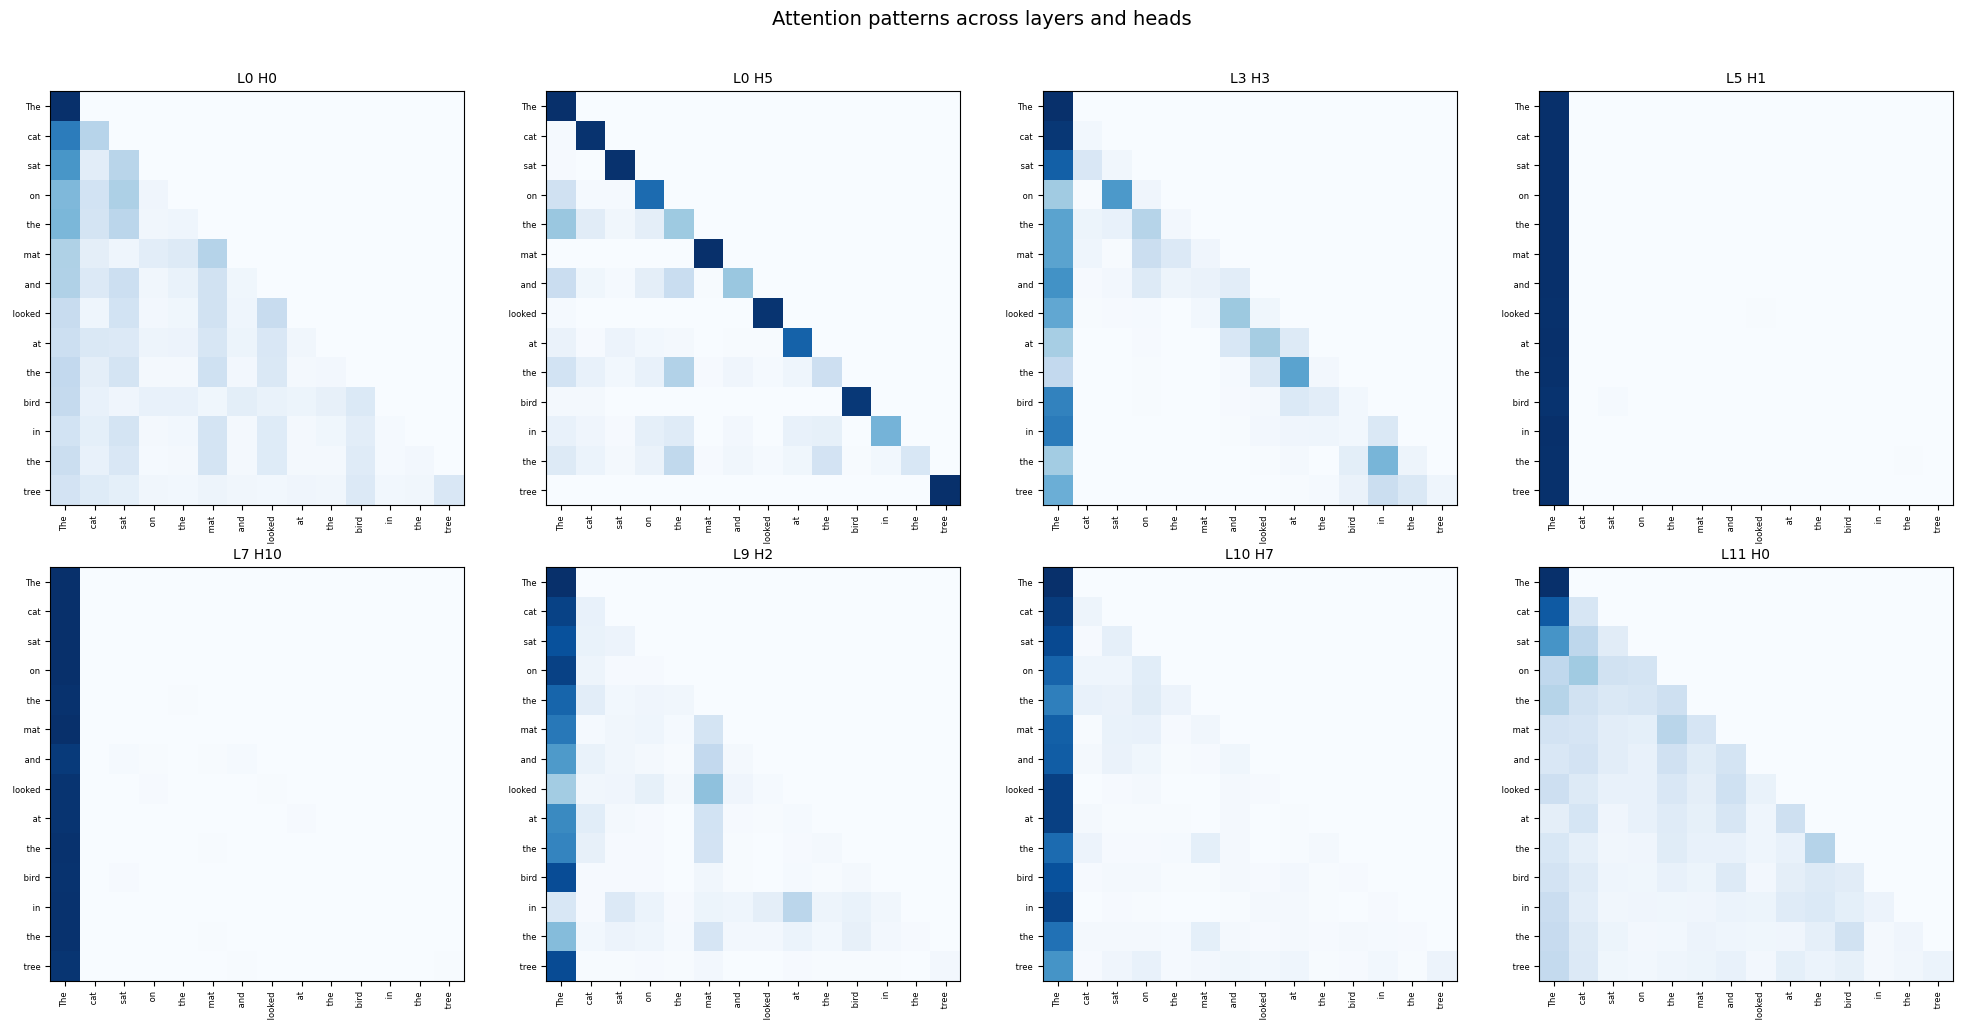

In [ ]:
# --- Visualize attention for selected heads ----------------------------------
# Show 4 heads from different layers to illustrate pattern diversity
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Pick interesting layers (early, middle, late) and heads
selections = [(0, 0), (0, 5), (3, 3), (5, 1),
              (7, 10), (9, 2), (10, 7), (11, 0)]

for idx, (layer, head) in enumerate(selections):
    ax = axes[idx // 4, idx % 4]
    attn = attentions[layer][head].numpy()
    ax.imshow(attn, cmap='Blues')
    ax.set_title(f'L{layer} H{head}', fontsize=10)
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(tokens_str, rotation=90, fontsize=6)
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(tokens_str, fontsize=6)

plt.suptitle('Attention patterns across layers and heads', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

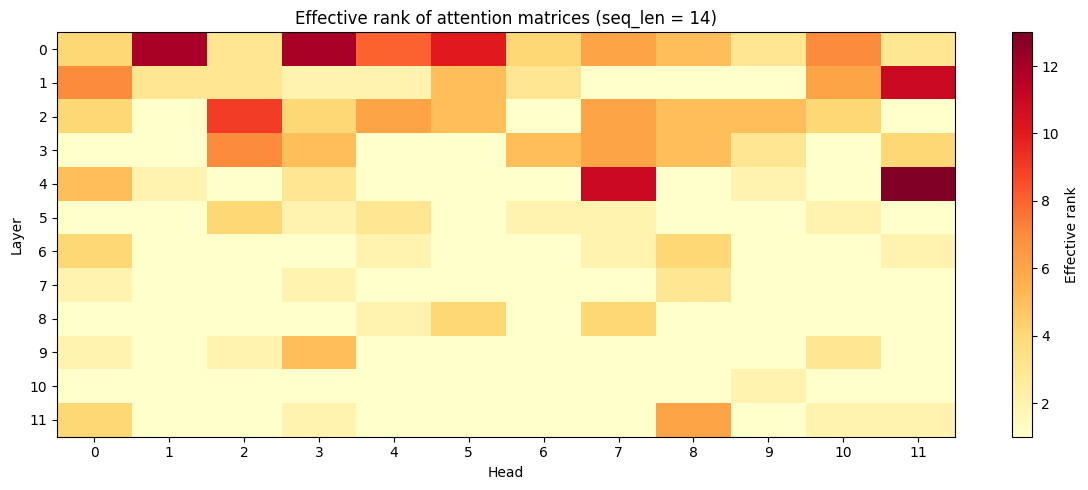

Effective rank statistics (out of max 14):
  Mean: 2.7
  Median: 1.0
  Min: 1, Max: 13
  Fraction with rank ≤ 3: 72.9%


In [ ]:
def effective_rank(A, threshold=0.95):
    '''Effective rank: smallest k capturing threshold of squared singular values.'''
    # TODO 1: Perform SVD (or just get singular values) on matrix A
    # TODO 2: Calculate cumulative variance explained by squared singular values (S**2)
    # TODO 3: Find the minimum index k that crosses the threshold percentage
    return 0

# Compute effective rank for every head in every layer
ranks = np.zeros((n_layers, n_heads))

# TODO 4: Iterate through layers and heads to populate the 'ranks' matrix
# Hint: Use attentions[layer][head]

# TODO 5: Plot a heatmap of the ranks using plt.imshow()
# Include axis labels for 'Head' and 'Layer' and a colorbar

## Part 3 — The residual stream across layers

The "residual stream" is the sequence of hidden states flowing through
the transformer. At each layer, the MHA and FFN add their contributions
to this stream (via residual connections).

We extract the hidden states at every layer and compute their SVD — the
same analysis we did on MLP hidden features in Week 3, but now on a
pretrained transformer.

In [ ]:
# --- Extract hidden states at every layer ------------------------------------
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

# hidden_states is a tuple: (embedding_output, after_layer_0, ..., after_layer_11)
hidden_states = [h.squeeze(0).cpu().numpy() for h in outputs.hidden_states]

print(f"Hidden states: {len(hidden_states)} tensors (embedding + {n_layers} layers)")
print(f"Each: {hidden_states[0].shape}  (seq_len × d_model)")

Hidden states: 13 tensors (embedding + 12 layers)
Each: (14, 768)  (seq_len × d_model)


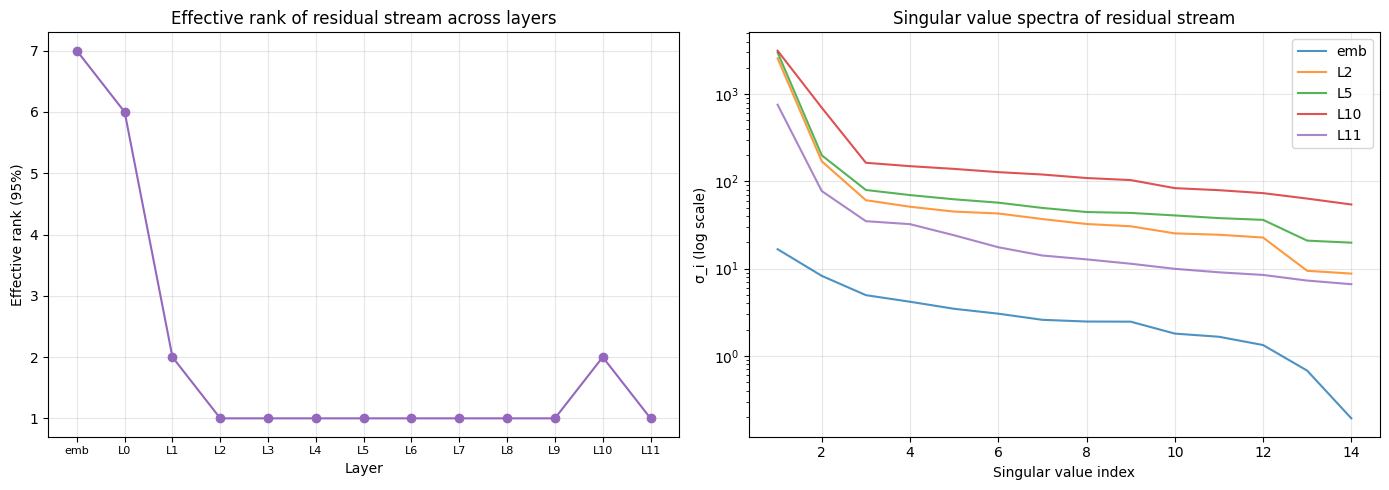

Effective rank across layers:
  embedding   : eff. rank = 7
  layer 0     : eff. rank = 6
  layer 1     : eff. rank = 2
  layer 2     : eff. rank = 1
  layer 3     : eff. rank = 1
  layer 4     : eff. rank = 1
  layer 5     : eff. rank = 1
  layer 6     : eff. rank = 1
  layer 7     : eff. rank = 1
  layer 8     : eff. rank = 1
  layer 9     : eff. rank = 1
  layer 10    : eff. rank = 2
  layer 11    : eff. rank = 1


In [ ]:
residual_ranks = []
residual_spectra = []

for i, h in enumerate(hidden_states):
    # TODO 1: Compute SVD for the hidden state tensor h
    # TODO 2: Calculate effective rank (95% threshold) and store in residual_ranks
    # TODO 3: Store the raw singular values in residual_spectra for plotting
    pass

# TODO 4: Create a 1x2 visualization:
# Plot 1: Line plot of effective rank vs Layer index
# Plot 2: Log-scale plot (semilogy) of singular value spectra for layers [0, 6, 11]

## Part 4 — Head importance and pruning

If many attention heads have low-rank patterns, some must be redundant.
Can we remove heads without hurting performance?

We measure head importance by **zeroing out** each head one at a time and
measuring the change in the model's output (cross-entropy loss on the
input text). Heads that cause a large loss increase when removed are
important; heads that barely change the loss are prunable.

In [ ]:
def measure_head_importance(model, inputs, tokenizer):
    '''Zero out each head one at a time and measure loss change.'''
    # TODO 1: Get baseline loss using model(**inputs, labels=inputs['input_ids'])

    importance = np.zeros((model.config.n_layer, model.config.n_head))

    # TODO 2: Loop through layers and heads
    # - Identify the weight slice for the specific head in c_proj (Hint: start = head_idx * dk)
    # - Save original weights, temporarily set weight slice to zero
    # - Measure new loss, calculate delta (new_loss - base_loss)
    # - Restore original weights

    return importance, 0.0

# TODO 3: Run the ablation function on a sample text and print the results

Measuring head importance (this may take a minute)...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Base loss: 4.2909


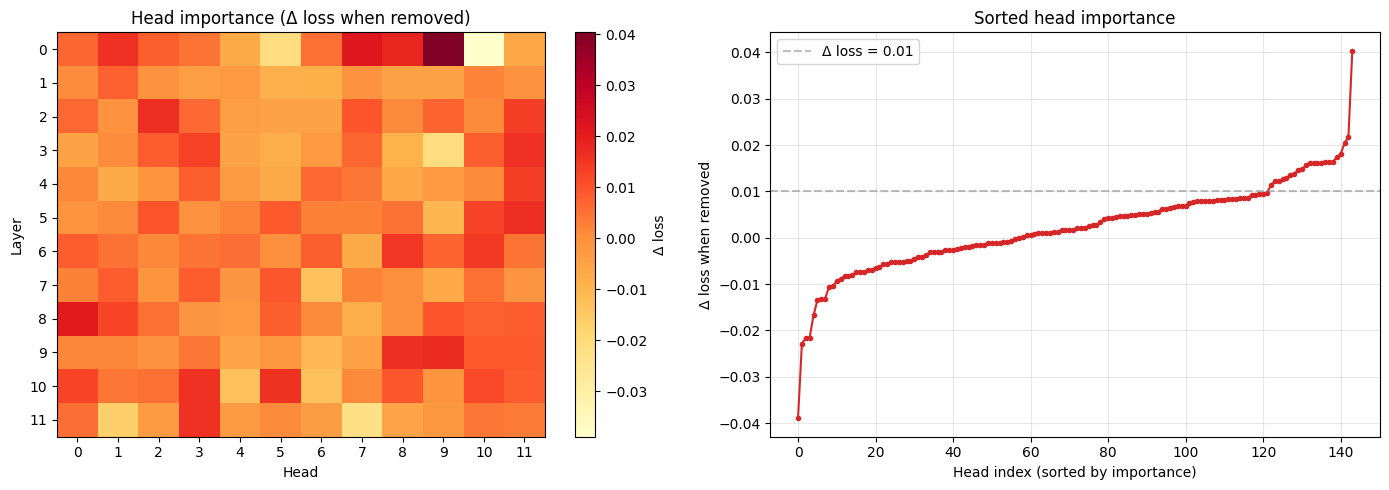

Heads with Δ loss < 0.01: 122 / 144 (85% prunable)
Most important: Layer 0, Head 9 (Δ loss = 0.0404)
Least important: Layer 0, Head 10 (Δ loss = -0.0390)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: heatmap of importance
ax = axes[0]
im = ax.imshow(importance, cmap='YlOrRd', aspect='auto')
ax.set_xlabel('Head'); ax.set_ylabel('Layer')
ax.set_title('Head importance (Δ loss when removed)')
ax.set_xticks(range(n_heads)); ax.set_yticks(range(n_layers))
plt.colorbar(im, ax=ax, label='Δ loss')

# Right: sorted importance — how many heads can be pruned?
ax = axes[1]
sorted_imp = np.sort(importance.flatten())
ax.plot(sorted_imp, 'o-', markersize=3, color='tab:red')
ax.axhline(0.01, color='gray', linestyle='--', alpha=0.5, label='Δ loss = 0.01')
ax.set_xlabel('Head index (sorted by importance)')
ax.set_ylabel('Δ loss when removed')
ax.set_title('Sorted head importance')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Count prunable heads
threshold = 0.01
n_prunable = (importance.flatten() < threshold).sum()
total_heads = n_layers * n_heads
print(f"Heads with Δ loss < {threshold}: {n_prunable} / {total_heads} "
      f"({n_prunable/total_heads:.0%} prunable)")

# Most and least important heads
flat = importance.flatten()
most_idx = np.unravel_index(flat.argmax(), importance.shape)
least_idx = np.unravel_index(flat.argmin(), importance.shape)
print(f"Most important: Layer {most_idx[0]}, Head {most_idx[1]} "
      f"(Δ loss = {importance[most_idx]:.4f})")
print(f"Least important: Layer {least_idx[0]}, Head {least_idx[1]} "
      f"(Δ loss = {importance[least_idx]:.4f})")

## Part 5 — The embedding space

The token embedding matrix $E \in \mathbb{R}^{V \times d}$ maps each of
the 50,257 tokens to a 768-dimensional vector. What structure does this
space have?

In [ ]:
# TODO 1: Extract the token embedding weight matrix (wte) from model.transformer
# TODO 2: Compute SVD and determine the effective rank at 95% variance
# TODO 3: Print the effective rank relative to the total dimension (768)

Token embedding matrix: torch.Size([50257, 768])
Effective rank (95%): 604 (out of 768)


In [ ]:
def nearest_neighbors(token_str, E, tokenizer, k=10):
    '''Find the k nearest tokens in embedding space.'''
    # TODO 1: Convert token_str to its ID using the tokenizer
    # TODO 2: Calculate cosine similarity between the target vector and all rows in E
    # Hint: Normalize vectors first for easy dot-product similarity
    # TODO 3: Use torch.topk to find the indices of the most similar tokens
    pass

# TODO 4: Test with words like 'king', 'cat', 'Python', and 'Paris'

Nearest neighbors of 'king' (token 3364):
   1. 'ked' (cos sim = 0.6833)
   2. 'KING' (cos sim = 0.5702)
   3. 'kers' (cos sim = 0.5579)
   4. 'King' (cos sim = 0.5314)
   5. 'ker' (cos sim = 0.5290)
   6. 'ks' (cos sim = 0.5084)
   7. 'ken' (cos sim = 0.4731)
   8. 'kes' (cos sim = 0.4595)
   9. 'ky' (cos sim = 0.4561)
  10. 'k' (cos sim = 0.4404)

Nearest neighbors of 'cat' (token 9246):
   1. 'cats' (cos sim = 0.6948)
   2. 'Cat' (cos sim = 0.6918)
   3. ' cat' (cos sim = 0.6032)
   4. ' Cat' (cos sim = 0.5690)
   5. ' cats' (cos sim = 0.4907)
   6. ' CAT' (cos sim = 0.4569)
   7. ' catcher' (cos sim = 0.4475)
   8. ' Cats' (cos sim = 0.4383)
   9. 'catching' (cos sim = 0.4216)
  10. 'cow' (cos sim = 0.3972)

Nearest neighbors of 'Python' (token 37906):
   1. ' Python' (cos sim = 0.7640)
   2. 'python' (cos sim = 0.7105)
   3. ' python' (cos sim = 0.6737)
   4. ' Django' (cos sim = 0.5460)
   5. 'ython' (cos sim = 0.5346)
   6. 'Ruby' (cos sim = 0.5299)
   7. '�' (cos sim = 0.5286)


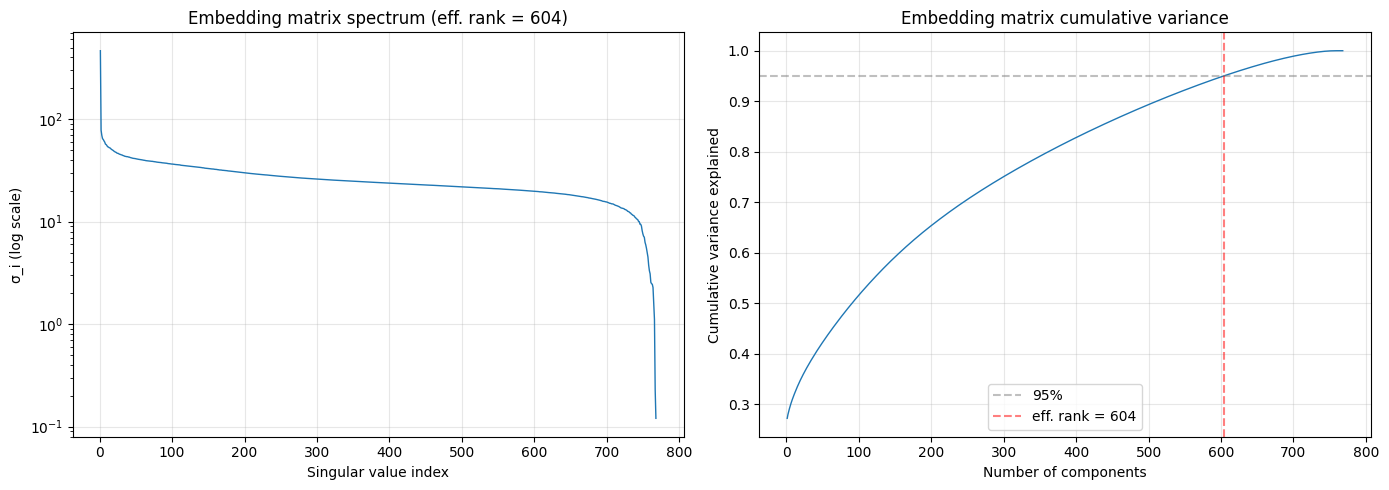

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: singular value spectrum of embedding matrix
ax = axes[0]
ax.semilogy(range(1, len(S_e)+1), S_e.numpy(), '-', color='tab:blue', linewidth=1)
ax.set_xlabel('Singular value index')
ax.set_ylabel('σ_i (log scale)')
ax.set_title(f'Embedding matrix spectrum (eff. rank = {eff_rank_emb})')
ax.grid(True, alpha=0.3)

# Right: cumulative variance
ax = axes[1]
ax.plot(range(1, len(var_exp)+1), var_exp.numpy(), '-', color='tab:blue', linewidth=1)
ax.axhline(0.95, color='gray', linestyle='--', alpha=0.5, label='95%')
ax.axvline(eff_rank_emb, color='red', linestyle='--', alpha=0.5,
           label=f'eff. rank = {eff_rank_emb}')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative variance explained')
ax.set_title('Embedding matrix cumulative variance')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 6 — Softmax temperature and attention sharpness

The standard attention uses $\text{softmax}(QK^\top / \sqrt{d_k})$. The
$\sqrt{d_k}$ is a specific choice of **temperature**. What happens if we
change it?

$$
A(T) = \text{softmax}\!\left(\frac{QK^\top}{T}\right)
$$

- $T \to 0$: hard attention — all mass on one token (argmax)
- $T = \sqrt{d_k}$: standard attention
- $T \to \infty$: uniform attention — every token gets equal weight

This connects to the entropy of the attention distribution: low $T$
produces low-entropy (peaked) attention, high $T$ produces high-entropy
(spread) attention.

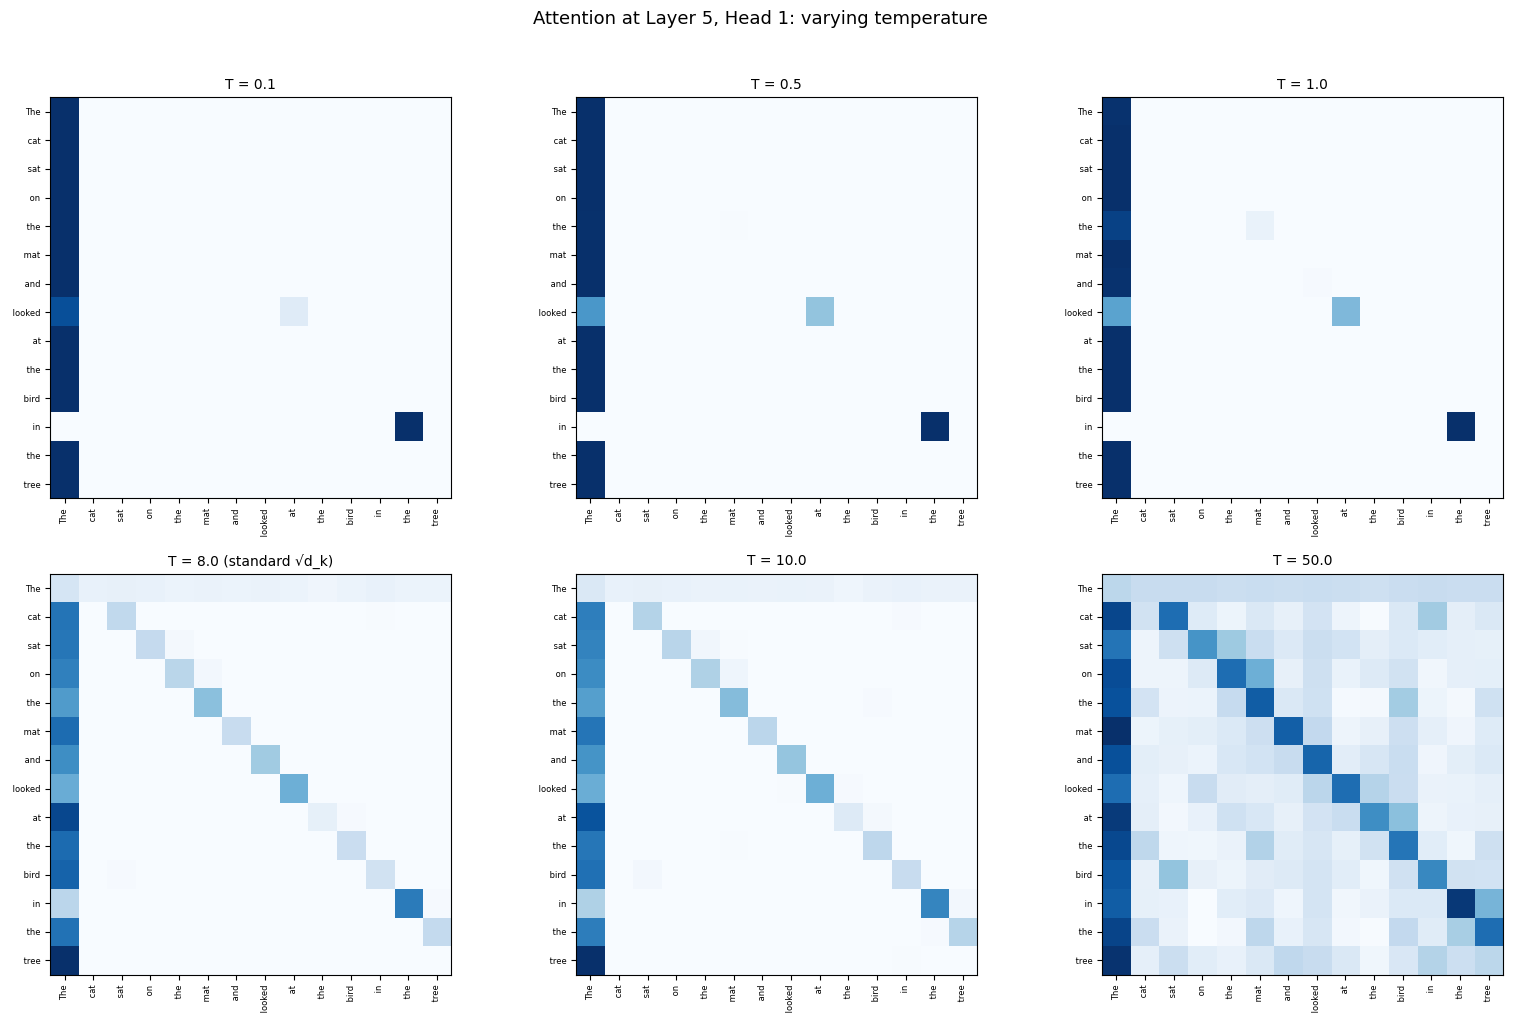

In [ ]:
# TODO 1: Select a specific layer and head index
# TODO 2: Manually compute raw attention scores (Q @ K.T) for the input sequence
# Hint: You'll need to pass hidden states through the layer's attention weights

# TODO 3: Apply F.softmax with varying temperatures [0.1, 1.0, 10.0, sqrt(dk)]
# TODO 4: Plot the resulting heatmaps to observe 'sharpness' vs 'smoothness'

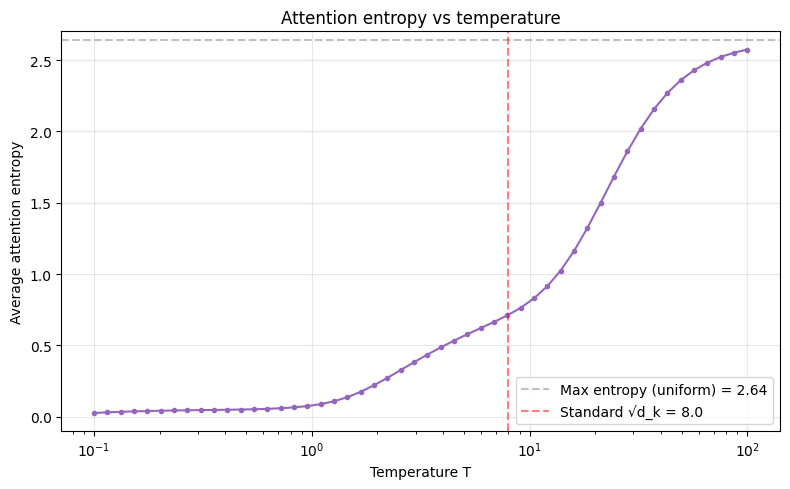

In [ ]:
# TODO 1: Define a range of temperature values (e.g., np.logspace(-1, 2))
# TODO 2: For each temperature, calculate the average entropy of the attention distribution
# Hint: H = -(p * log(p)).sum()

# TODO 3: Plot Entropy vs Temperature on a semilogx scale
# TODO 4: Mark the point where T = sqrt(dk) (the standard scaling)